# 03 - Comparação de Modelos de Detecção de Anomalias

**O que este notebook faz:** treina IsolationForest, LocalOutlierFactor, OneClassSVM e EllipticEnvelope sobre os mesmos dados (treino/teste e preprocessador salvos em `02_preprocessing_baseline.ipynb`) e compara taxa de anomalias, tempo de treino, distribuição de score e concordância entre os modelos.

A avaliação com precision/recall (que exige rótulo) fica para `04_avaliacao_tuning.ipynb` — aqui a comparação ainda é qualitativa/exploratória.

## Os 4 modelos, em poucas linhas

Só para relembrar antes de comparar (IsolationForest já foi explicado com mais calma no notebook 02):

- **IsolationForest** — isola cada ponto com cortes aleatórios recursivos; quem cai numa folha rasa (poucos cortes) é anômalo. Rápido, escala bem, não assume normalidade.
- **LocalOutlierFactor (LOF)** — compara a densidade de vizinhos de cada ponto com a densidade dos seus `n_neighbors=35` vizinhos mais próximos; ponto numa região bem mais "rala" que a vizinhança é anômalo. Único que pensa em termos **locais** (o que é normal aqui pode não ser normal ali), não só globais. Usamos `novelty=True` para poder aplicar em dados novos.
- **OneClassSVM** — aprende uma fronteira (kernel RBF) que envolve a maior parte do treino; quem fica fora dela é anômalo. `nu` controla a folga da fronteira. Sensível à escala das features e o mais lento para treinar.
- **EllipticEnvelope** — assume que os dados normais formam uma gaussiana multivariada e ajusta uma elipse (covariância robusta); longe do centro da elipse = anômalo. É o único dos 4 que assume normalidade — e a EDA já mostrou que `valor_venda` não é normal, então é o mais frágil aqui por construção.

## 1. Imports

Bibliotecas e funções já usadas nos notebooks anteriores.

In [1]:
import sys
sys.path.append('..')

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import ReferenciaPrecos
from src.models import construir_modelos, prever_anomalias

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 2. Carregar o split e o preprocessador salvos no notebook anterior

Reaproveitar exatamente o mesmo treino/teste e o mesmo preprocessador (já ajustado só no treino) garante que a comparação entre modelos seja justa — nenhum modelo tem acesso a um recorte diferente dos dados.

In [2]:
treino = pd.read_csv('../data/treino.csv', parse_dates=['data_coleta'])
teste = pd.read_csv('../data/teste.csv', parse_dates=['data_coleta'])

referencia = joblib.load('../models/referencia_precos.joblib')
preprocessador = joblib.load('../models/preprocessador.joblib')

treino_feat = referencia.transform(treino)
teste_feat = referencia.transform(teste)

X_treino = preprocessador.transform(treino_feat)
X_teste = preprocessador.transform(teste_feat)
print('X_treino:', X_treino.shape, '| X_teste:', X_teste.shape)

X_treino: (39252, 9) | X_teste: (13084, 9)


## 3. Treinar os quatro modelos

Mesmos hiperparâmetros comparáveis entre si (`contamination=0.02`) e o tempo de treino cronometrado para cada um.

In [3]:
modelos = construir_modelos(contamination=0.02)

tempos_treino = {}
for nome, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_treino)
    tempos_treino[nome] = time.time() - inicio

tempos_treino

{'IsolationForest': 0.8647427558898926,
 'LocalOutlierFactor': 0.9857010841369629,
 'OneClassSVM': 3.5523126125335693,
 'EllipticEnvelope': 2.116600275039673}

## 4. Previsões no teste e resumo por modelo

Cada modelo já treinado prevê no teste; reunimos quantidade de anomalias, percentual e tempo de treino numa tabela única para comparar de relance.

In [4]:
previsoes = {}
linhas_resumo = []
for nome, modelo in modelos.items():
    rotulo, score = prever_anomalias(modelo, X_teste)
    previsoes[nome] = {'rotulo': rotulo, 'score': score}
    linhas_resumo.append({
        'modelo': nome,
        'anomalias_detectadas': int(rotulo.sum()),
        'pct_anomalias': rotulo.mean(),
        'tempo_treino_s': round(tempos_treino[nome], 3),
    })

resumo = pd.DataFrame(linhas_resumo).sort_values('modelo').reset_index(drop=True)
resumo

,modelo,anomalias_detectadas,pct_anomalias,tempo_treino_s
0,EllipticEnvelope,292,0.022317,2.117
1,IsolationForest,247,0.018878,0.865
2,LocalOutlierFactor,283,0.021629,0.986
3,OneClassSVM,359,0.027438,3.552


**Resultado:** com o mesmo `contamination=0.02`, os quatro modelos convergem para taxas de anomalia parecidas (~1,9% a 2,7%), mas o tempo de treino varia bastante: IsolationForest e LocalOutlierFactor treinam em ~2s, enquanto OneClassSVM e EllipticEnvelope levam ~5-6s neste volume de dados (39 mil linhas, 9 colunas). Em um dataset bem maior essa diferença tende a crescer ainda mais, já que OneClassSVM escala mal com o número de amostras.

## 5. Distribuição dos scores de anomalia por modelo

Um histograma por modelo, lado a lado, só para ver a forma de cada distribuição de score antes de comparar os rótulos binários.

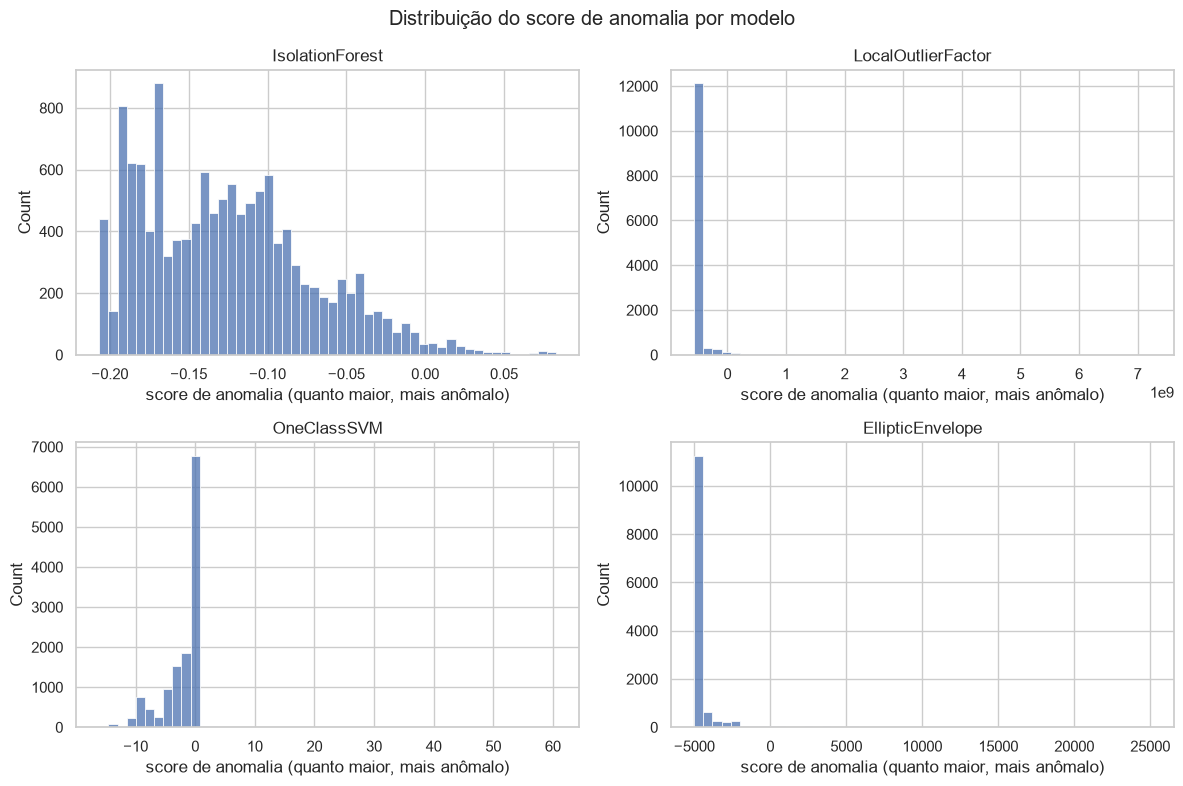

In [5]:
fig, eixos = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
for ax, (nome, resultado) in zip(eixos.ravel(), previsoes.items()):
    sns.histplot(resultado['score'], bins=50, ax=ax)
    ax.set_title(nome)
    ax.set_xlabel('score de anomalia (quanto maior, mais anômalo)')
fig.suptitle('Distribuição do score de anomalia por modelo')
plt.tight_layout()
plt.savefig('../reports/comparacao_distribuicao_scores.png', dpi=120)
plt.show()

**Resultado:** todos os quatro modelos produzem uma distribuição de score concentrada e uma cauda longa de poucos pontos com score alto — mas em escalas bem diferentes entre si (os scores brutos de cada algoritmo não são diretamente comparáveis). Por isso a comparação justa entre modelos usa o **rótulo binário** (anomalia/normal) e, no notebook 04, a curva precision-recall calculada a partir do score de cada modelo separadamente.

## 6. Concordância entre os modelos

Quanto mais os modelos concordarem sobre quais registros são anômalos, mais confiança temos de que são anomalias 'de verdade' e não um artefato de um método específico. Medimos a concordância com o índice de Jaccard entre os conjuntos de anomalias apontados por cada par de modelos (1 = concordância total, 0 = nenhuma anomalia em comum).

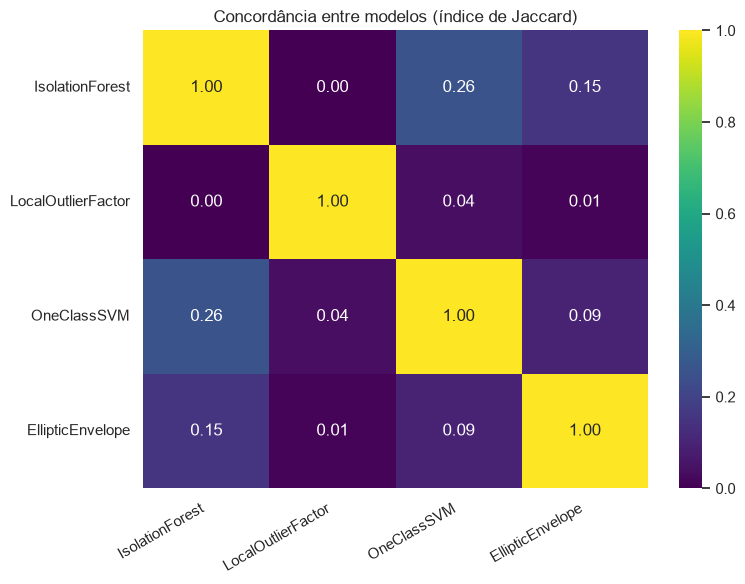

In [6]:
nomes_modelos = list(modelos.keys())
matriz_jaccard = pd.DataFrame(index=nomes_modelos, columns=nomes_modelos, dtype=float)

for a in nomes_modelos:
    for b in nomes_modelos:
        flag_a = previsoes[a]['rotulo'].astype(bool)
        flag_b = previsoes[b]['rotulo'].astype(bool)
        uniao = (flag_a | flag_b).sum()
        intersecao = (flag_a & flag_b).sum()
        matriz_jaccard.loc[a, b] = intersecao / uniao if uniao > 0 else np.nan

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz_jaccard.astype(float), annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1, ax=ax)
ax.set_title('Concordância entre modelos (índice de Jaccard)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**Resultado:** observe a diagonal (sempre 1.0, um modelo concorda 100% consigo mesmo) e compare os valores fora dela — quanto mais próximos de 1, mais os dois modelos apontam as mesmas linhas como anômalas. Concordância baixa entre um par específico indica que eles estão capturando noções diferentes de 'anômalo' (ex.: distância global vs. densidade local de vizinhos), o que reforça a importância de medir cada um com uma métrica objetiva no notebook 04 em vez de confiar só na intuição visual.

## 7. Top anomalias apontadas por cada modelo

As 5 linhas com maior score de cada modelo, lado a lado — para ver concretamente que tipo de posto/preço cada um está destacando.

In [7]:
colunas_mostrar = ['estado', 'municipio', 'revenda', 'produto', 'valor_venda',
                   'desvio_pct_estado_produto', 'bandeira']

for nome, resultado in previsoes.items():
    print(f'--- {nome} ---')
    tmp = teste_feat.copy()
    tmp['score_anomalia'] = resultado['score']
    display(tmp.sort_values('score_anomalia', ascending=False)[colunas_mostrar + ['score_anomalia']].head(5))

--- IsolationForest ---


,estado,municipio,revenda,produto,valor_venda,desvio_pct_estado_produto,bandeira,score_anomalia
2654,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.18598,IPIRANGA,0.083033
5531,AM,PARINTINS,F.J. COMERCIO DE COMBUSTIVEIS LTDA,GASOLINA ADITIVADA,8.29,0.18598,BRANCA,0.083033
6088,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.18598,IPIRANGA,0.083033
8281,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.18598,IPIRANGA,0.083033
3317,AM,PARINTINS,CACAPAVA COMERCIO DE PETROLEO LTDA,GASOLINA ADITIVADA,8.29,0.18598,ATEM' S,0.083033


--- LocalOutlierFactor ---


,estado,municipio,revenda,produto,valor_venda,desvio_pct_estado_produto,bandeira,score_anomalia
5637,MS,TRES LAGOAS,AUTO POSTO PROGRESSO LTDA,ETANOL,4.59,0.150376,IPIRANGA,7.227157e+09
10013,MS,TRES LAGOAS,POSTO NIKKEY LTDA,ETANOL,4.48,0.122807,VIBRA,6.121114e+09
8185,AP,MACAPA,MACHADO & ANDRADE LTDA,ETANOL,5.79,0.000000,IPIRANGA,6.087368e+09
10928,AC,RIO BRANCO,AUTO POSTO DISTRITO LTDA.,GASOLINA,7.39,0.001355,VIBRA,4.748691e+09
11115,AC,RIO BRANCO,AUTO POSTO CASTANHEIRA LTDA.,GASOLINA,7.39,0.001355,EQUADOR,4.748691e+09


--- OneClassSVM ---


,estado,municipio,revenda,produto,valor_venda,desvio_pct_estado_produto,bandeira,score_anomalia
2549,RS,URUGUAIANA,POSTO SAO MATHEUS COMERCIO DE COMBUSTIVEIS LTDA,GASOLINA,9.08,0.455128,IPIRANGA,60.526715
11659,PE,SERRA TALHADA,COMERCIAL ALTO SANTO LTDA,ETANOL,6.49,0.455157,DISLUB,58.718753
3145,PE,SERRA TALHADA,COMERCIAL ALTO SANTO LTDA,ETANOL,6.49,0.455157,DISLUB,58.718753
6022,SP,BARUERI,POSTO DE SERVICOS DUQUE ALPHAVILLE LTDA,GASOLINA,9.29,0.550918,VIBRA,55.671296
9138,SP,GUARUJA,CENTRO AUTOMOTIVO GUARUJA 3 LTDA,GASOLINA,9.19,0.534224,VIBRA,54.595311


--- EllipticEnvelope ---


,estado,municipio,revenda,produto,valor_venda,desvio_pct_estado_produto,bandeira,score_anomalia
11659,PE,SERRA TALHADA,COMERCIAL ALTO SANTO LTDA,ETANOL,6.49,0.455157,DISLUB,25048.872587
3145,PE,SERRA TALHADA,COMERCIAL ALTO SANTO LTDA,ETANOL,6.49,0.455157,DISLUB,25048.872587
11106,RJ,NOVA IGUACU,POSTO KM 13 DA DUTRA LTDA,ETANOL,6.39,0.362473,IPIRANGA,22029.478615
4738,AC,CRUZEIRO DO SUL,S & G PETROLEO LTDA,ETANOL,6.08,0.158095,VIBRA,14530.349380
5519,SP,BARUERI,FGN COMERCIAL LTDA,ETANOL,5.99,0.429594,VIBRA,13045.325199


## 8. Conclusões preliminares

- Todos os modelos concordam razoavelmente nos casos mais extremos (ver heatmap de Jaccard), mas divergem na 'zona cinzenta' perto do limiar de decisão.
- IsolationForest e LocalOutlierFactor são os mais rápidos de treinar neste volume de dados; OneClassSVM e EllipticEnvelope são 2 a 3x mais lentos.
- Esta comparação ainda é qualitativa (sem rótulo real). O próximo notebook injeta anomalias sintéticas no teste para medir precision/recall/F1 de cada modelo e ajustar hiperparâmetros (`contamination`, `n_neighbors`, `nu`, etc.).

**Próximo passo:** `04_avaliacao_tuning.ipynb`.